# Doğrusal Regresyon ile Öğrenci Başarı Analizi (Linear Regression)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
!pip install -q gdown
import gdown

gdown.download('https://drive.google.com/uc?id=1b2JYWIxkFoYcTpVASEz2kWKfCN27_TcL', 'ogrenci_calisma_notlari.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1b2JYWIxkFoYcTpVASEz2kWKfCN27_TcL
To: /content/ogrenci_calisma_notlari.csv
100%|██████████| 734/734 [00:00<00:00, 685kB/s]


'ogrenci_calisma_notlari.csv'

In [ ]:
df = pd.read_csv("ogrenci_calisma_notlari.csv")
print(df.head())
print(df.shape)

   calisma_saati  sinav_notu
0            0.6          29
1            0.7          33
2            0.8          29
3            0.9          36
4            1.0          22
(100, 2)


In [ ]:
X = df[["calisma_saati"]]
y = df["sinav_notu"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim kümesi boyutu:", X_train.shape)
print("Test kümesi boyutu:", X_test.shape)

Eğitim kümesi boyutu: (80, 1)
Test kümesi boyutu: (20, 1)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

egim = model.coef_[0]
kesisim = model.intercept_

print("Eğim (b):", egim)
print("Kesişim (a):", kesisim)

Eğim (b): 5.940998380623813
Kesişim (a): 23.6559177638527


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R^2 (test):", r2)

MSE: 34.94174063316996
RMSE: 5.911153917228848
R^2 (test): 0.8912243172419237


In [ ]:
yeni_saat = pd.DataFrame({"calisma_saati": [6]})
tahmin = model.predict(yeni_saat)
print("6 saat çalışan öğrencinin tahmini notu:", tahmin[0])

6 saat çalışan öğrencinin tahmini notu: 59.301908047595575


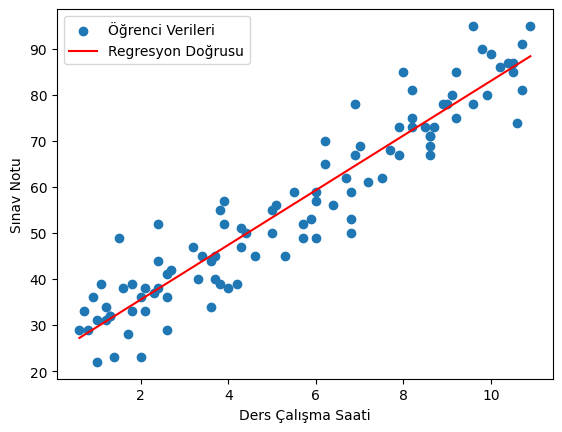

In [ ]:
plt.scatter(X, y, label="Öğrenci Verileri")
plt.plot(X, model.predict(X), color="red", label="Regresyon Doğrusu")
plt.xlabel("Ders Çalışma Saati")
plt.ylabel("Sınav Notu")
plt.legend()
plt.show()